# Responsible AI for 30-Day Hospital Readmission
## Patients with diabetes — discharge-time risk stratification

**Scope:** This is retrospective educational analysis, not a validated clinical tool. The historical outcome is recorded readmission **<30 days after discharge**, not necessarily preventable or diabetes-caused readmission.

| Step | Weight | Ownership/status |
|---|---:|---|
| 1. Clinical framing | 10% | First half |
| 2. Data characterization | 10% | First half |
| 3. Experimental design | 5% | First half |
| 4. Pipelines and leakage controls | 10% | First half |
| 5. Discrimination analysis | 15% | First half |
| 6. Calibration | 8% | Group handoff |
| 7. Threshold selection | 8% | Group handoff |
| 8. Final test evaluation | 4% | Group handoff — test remains unevaluated |
| 9. RAI Toolbox | 30% | Group handoff |

**Run:** Use the project Python 3.10 environment and run cells in order. The data cell downloads the public UCI files if absent, verifies their SHA-256 hashes, and stores them in `Data/`. Generated tables, figures, split assignments, and the uncalibrated model go to `artifacts/`. Code templates after the handoff remain commented. First-half outputs are saved in this notebook.


In [38]:
from pathlib import Path
from itertools import combinations
import csv
import hashlib
import io
import json
import platform
import urllib.request
import warnings
import zipfile
from importlib.metadata import version

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibrationDisplay

RANDOM_STATE = 42
DATA_DIR = Path("Data")
ARTIFACT_DIR = Path("artifacts")
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
DATA_PATH = DATA_DIR / "diabetic_data.csv"
MAPPING_PATH = DATA_DIR / "IDS_mapping.csv"
TARGET = "readmitted_30d"
PATIENT_ID = "patient_nbr"
DATA_URL = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"
# Prospective classroom assumptions, not selected or validated operating points.
ALERT_BUDGET_PER_1000 = 200
ALTERNATIVE_ALERT_BUDGET_PER_1000 = 250
RECALL_FLOOR = 0.85
PRECISION_ASPIRATION = 0.40
N_BOOTSTRAP = 300
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150})
set_config(display="diagram")
versions = {name: version(name) for name in [
    "numpy", "pandas", "scipy", "scikit-learn", "matplotlib", "seaborn", "joblib", "nbformat", "nbclient"
]}
versions["python"] = platform.python_version()
display(pd.Series(versions, name="Executed environment").to_frame())
(ARTIFACT_DIR / "versions.json").write_text(json.dumps(versions, indent=2) + "\n")


,Executed environment
numpy,1.26.2
pandas,1.5.3
scipy,1.13.1
scikit-learn,1.5.1
matplotlib,3.9.2
seaborn,0.13.2
joblib,1.6.0
nbformat,5.11.1
nbclient,0.11.0
python,3.10.21


233

## 1. Clinical problem framing and study objective

**Question:** At discharge, can routine encounter information identify patients with recorded diabetes at increased risk of recorded inpatient readmission in fewer than 30 days, to prioritize follow-up and diabetes education?

| Element | Study decision |
|---|---|
| Population | Age 20+, source-defined diabetes encounters, documented home/outpatient departure (including AMA) |
| Prediction time | Discharge, when encounter totals and in-hospital medication changes are available |
| Action | Nurse/case-manager review, education, appointment scheduling, or follow-up call |
| Comparison | Training-prevalence baseline versus a prespecified logistic-regression pipeline |
| Outcome | `readmitted == "<30"`; `>30` and `NO` are negative |
| Analysis unit | Eligible discharge encounter; repeated patients retained but isolated across splits |
| Success in Steps 1–5 | Quantify AP/ROC AUC improvement over baseline and uncertainty; no target performance promised |
| Later policy aspirations | Investigate 85% recall, 40% precision, and budgets of 200/250 contacts per 1,000; report infeasibility if needed |

**Eligibility:** The source already selected diabetes-coded inpatient encounters with 1–14 day stays, laboratory tests, and medication administration. Do not reselect using only the three released diagnosis fields. Age is binned: 20+ conservatively excludes 18–19-year-olds along with younger patients. Discharge codes 1, 6, 7, 8, 16, 17 define our home/outpatient follow-up cohort. Retain transfers into the index hospital and AMA departures; do not automatically remove vulnerable patients. Exclude deaths, hospice, institutional transfers, ongoing stays, and unknown destinations. This is narrower than all adult diabetes admissions.

**Why no clinician or LACE comparison:** Clinician risk judgments are not recorded, and a valid LACE comparison would require confirming that all four components can be reconstructed from this extract. These remain potential future comparisons, not evaluations this analysis supports.

**Harms and mitigations**

| Harm | Description | Mitigation |
|---|---|---|
| False negatives | Patients later readmitted are not prioritized | Report recall/FNR; keep standard discharge care for everyone |
| False positives | Extra contacts, patient burden, diverted staff time | Use an explicit total-alert budget and communicate uncertainty |
| Unequal errors | Groups may differ in missed cases or unnecessary contacts | Report subgroup metrics, event counts, uncertainty, and calibration |
| Over-reliance | Staff treat the score as definitive clinical judgment | Retain clinician review; state the intended use |
| Misread benefit | High risk is confused with preventable or intervention-responsive risk | Separate risk prediction from treatment-effect claims |

**Constraints:** Historical 1999–2008 data from institutions participating in one EHR warehouse; out-of-network readmissions uncaptured; age bands prevent exact 18+ definition; limited social information; no usable dates or hospital identifiers for temporal/site splits; no evaluated follow-up intervention. These are deidentified clinical records, not synthetic data.

**Success criteria caution:** Do not treat Brier ≤0.18 as a target. At a prevalence near 0.11, a constant prevalence prediction already has an expected Brier near 0.099. Fit the prevalence baseline on training data and score it on the designated evaluation partition.

**Illustrative patient impact — hypothetical, not a result:** If the cohort readmission rate were 11.16% and a model achieved 85% recall at 40% precision, 1,000 discharges would produce roughly **237 contacts**, of which about **95** had a recorded early readmission, about **142** did not, and about **17** early readmissions were missed. Recalculate with measured validation performance. This assumes one contact per flagged discharge and describes workload and case finding — **not readmissions prevented**.

**Limits:** CMS HRRP is broader policy context, not a standalone diabetes penalty measure; its penalties postdate these records. No causal claim follows from this analysis.

**So what?** The model would support a discharge team choosing whom to contact, not decide who deserves care. Whether that prioritization is useful depends on later calibration, workload trade-offs, and prospective intervention evaluation.

## 2. Data characterization and representativeness

**Provenance:** [UCI dataset](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008), Clore et al. (2014), DOI [10.24432/C5230J](https://doi.org/10.24432/C5230J), **CC BY 4.0**. Real deidentified clinical records, not synthetic data. The [source paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC3996476/) describes the Cerner Health Facts warehouse, participating hospitals, and absent out-of-network capture.

The download's `?` values denote missing information. Literal `None` in HbA1c/glucose fields means **not measured**, not an empty cell. Medication `No` means not prescribed during the encounter. These categories remain intact.

**Ordering safeguard:** Reserve patients immediately after deterministic eligibility filtering, before outcome-based EDA. Step 2 tables/plots describe **training data only**; cohort-flow counts describe all source records without reading held-out outcome distributions. Step 3 explains the partition design.


In [39]:
EXPECTED_SHA256 = {'diabetic_data.csv': '0689e7ec031237dc63031b938805c48377748761a3b26acab621567afa24df97', 'IDS_mapping.csv': 'f1bb82b471cb34649352597572c9b1fb00bd27f77b9f5a22a03dc3eb1039749e'}
if not all((DATA_DIR / name).exists() for name in EXPECTED_SHA256):
    with urllib.request.urlopen(DATA_URL, timeout=60) as response:
        archive_bytes = response.read()
    with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
        for name in EXPECTED_SHA256:
            member = next(m for m in archive.namelist() if m.rsplit("/", 1)[-1] == name)
            (DATA_DIR / name).write_bytes(archive.read(member))
actual_hashes = {name: hashlib.sha256((DATA_DIR / name).read_bytes()).hexdigest()
                 for name in EXPECTED_SHA256}
assert actual_hashes == EXPECTED_SHA256, "Source differs from the documented release; investigate before proceeding."
(ARTIFACT_DIR / "data_provenance.json").write_text(json.dumps({
    "url": DATA_URL, "license": "CC BY 4.0", "sha256": actual_hashes
}, indent=2) + "\n")
raw = pd.read_csv(DATA_PATH, keep_default_na=False, na_values=["?"], low_memory=False)
assert raw["encounter_id"].is_unique
assert raw[PATIENT_ID].notna().all()
assert raw["age"].isin([f"[{n}-{n + 10})" for n in range(0, 100, 10)]).all()
assert raw["readmitted"].isin(["<30", ">30", "NO"]).all()
assert raw["time_in_hospital"].between(1, 14).all()
raw[TARGET] = raw["readmitted"].eq("<30").astype("int8")

# Parse the three independently headed mapping sections, not one flat CSV table.
mappings = {}
section = None
for row in csv.reader(MAPPING_PATH.read_text().splitlines()):
    if not row or not row[0].strip():
        continue
    if row[0].endswith("_id"):
        section = row[0]
        mappings[section] = {}
    else:
        mappings[section][int(row[0])] = row[1].strip()
discharge_map = mappings["discharge_disposition_id"]
assert set(raw["discharge_disposition_id"]) <= set(discharge_map)
discharge_audit = pd.DataFrame({
    "code": sorted(discharge_map),
    "description": [discharge_map[k] for k in sorted(discharge_map)]
})
discharge_audit["source_encounters"] = discharge_audit["code"].map(
    raw["discharge_disposition_id"].value_counts()).fillna(0).astype(int)
display(discharge_audit)
discharge_audit.to_csv(ARTIFACT_DIR / "discharge_mapping_audit.csv", index=False)


,code,description,source_encounters
0,1,Discharged to home,60234
1,2,Discharged/transferred to another short term h...,2128
2,3,Discharged/transferred to SNF,13954
3,4,Discharged/transferred to ICF,815
4,5,Discharged/transferred to another type of inpa...,1184
5,6,Discharged/transferred to home with home healt...,12902
6,7,Left AMA,623
7,8,Discharged/transferred to home under care of H...,108
8,9,Admitted as an inpatient to this hospital,21
9,10,Neonate discharged to another hospital for neo...,6


In [40]:
HOME_OUTPATIENT_CODES = {1, 6, 7, 8, 16, 17}
DEATH_HOSPICE_CODES = {11, 13, 14, 19, 20, 21}
FACILITY_CODES = {2, 3, 4, 5, 10, 15, 22, 23, 24, 27, 28, 29, 30}
# Other destinations (9, 12, 18, 25, 26) do not establish a completed,
# eligible home/outpatient discharge. Exclusion is a scope choice, not low risk.
cohort = raw.copy()
flow_rows = []
def record_flow(stage, frame, previous_count):
    flow_rows.append({"stage": stage, "removed_encounters": previous_count - len(frame),
                      "encounters": len(frame), "patients": frame[PATIENT_ID].nunique()})
record_flow("Source encounters", cohort, len(cohort))
filters = [
    ("Age 20+", ~cohort["age"].isin(["[0-10)", "[10-20)"])),
    ("Exclude death / hospice", ~cohort["discharge_disposition_id"].isin(DEATH_HOSPICE_CODES)),
    ("Exclude facility transfers", ~cohort["discharge_disposition_id"].isin(FACILITY_CODES)),
    ("Documented home / outpatient departure", cohort["discharge_disposition_id"].isin(HOME_OUTPATIENT_CODES)),
]
for stage, mask in filters:
    previous_count = len(cohort)
    cohort = cohort.loc[mask.loc[cohort.index]].copy()
    record_flow(stage, cohort, previous_count)
cohort = cohort.sort_values("encounter_id").reset_index(drop=True)
flow_table = pd.DataFrame(flow_rows)
display(flow_table)
flow_table.to_csv(ARTIFACT_DIR / "cohort_flow.csv", index=False)

# Define audits without learning any distribution-dependent transformations.
cohort["age_group"] = cohort["age"].map({
    "[20-30)": "20–39", "[30-40)": "20–39", "[40-50)": "40–59", "[50-60)": "40–59",
    "[60-70)": "60–79", "[70-80)": "60–79", "[80-90)": "80+", "[90-100)": "80+",
})
for col in ["race", "gender", "payer_code"]:
    cohort[col + "_audit"] = cohort[col].fillna("Missing").replace({"Unknown/Invalid": "Missing"})

def split_by_patient(frame, test_size):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_STATE)
    left, right = next(splitter.split(frame, groups=frame[PATIENT_ID]))
    return frame.iloc[left].copy(), frame.iloc[right].copy()

train_df, holdout_df = split_by_patient(cohort, 0.30)
validation_df, test_df = split_by_patient(holdout_df, 0.50)
calibration_df, policy_df = split_by_patient(validation_df, 0.50)
partitions = {"train": train_df, "calibration": calibration_df, "policy": policy_df, "test": test_df}
patient_sets = {name: set(frame[PATIENT_ID]) for name, frame in partitions.items()}
for left, right in combinations(patient_sets, 2):
    assert patient_sets[left].isdisjoint(patient_sets[right])
assert sum(len(frame) for frame in partitions.values()) == len(cohort)
manifest = pd.concat([frame[["encounter_id", PATIENT_ID]].assign(partition=name)
                      for name, frame in partitions.items()], ignore_index=True)
assert manifest["encounter_id"].is_unique
manifest.to_csv(ARTIFACT_DIR / "split_manifest.csv", index=False)
# No test-label summary or test predictions. Membership alone is recorded.


,stage,removed_encounters,encounters,patients
0,Source encounters,0,101766,71518
1,Age 20+,852,100914,70840
2,Exclude death / hospice,2421,98493,69314
3,Exclude facility transfers,20734,77759,57460
4,Documented home / outpatient departure,4668,73091,54642


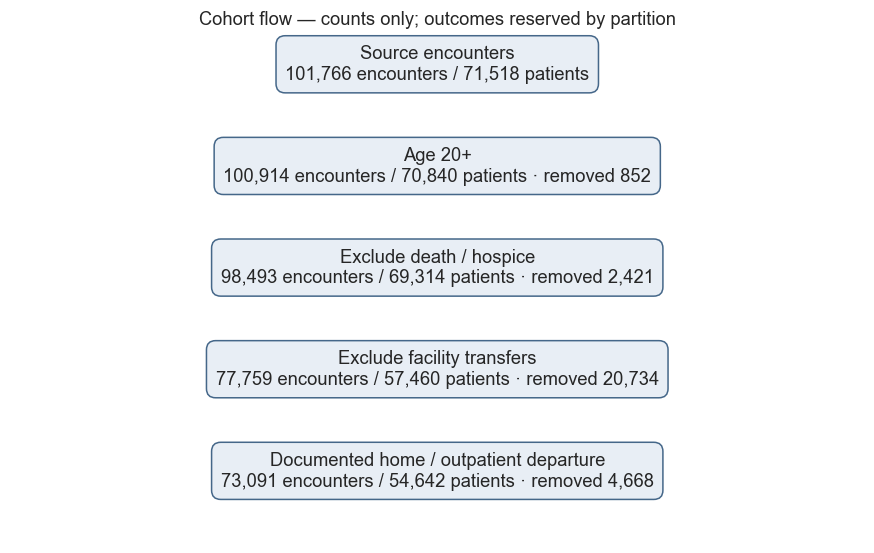

,group,encounters,patients,early_readmissions,prevalence,share_of_training,attribute
0,20–39,3562,2570,400,0.1123,0.0695,age_group
1,40–59,15764,11858,1427,0.0905,0.3076,age_group
2,60–79,24619,18667,2486,0.1010,0.4803,age_group
3,80+,7308,5543,820,0.1122,0.1426,age_group
4,Female,26697,19782,2650,0.0993,0.5209,gender_audit
5,Male,24555,18467,2483,0.1011,0.4791,gender_audit
6,Missing,1,1,0,0.0000,0.0000,gender_audit
7,AfricanAmerican,10098,7169,1052,0.1042,0.1970,race_audit
8,Asian,370,301,33,0.0892,0.0072,race_audit
9,Caucasian,37730,28277,3842,0.1018,0.7362,race_audit


,time_in_hospital,number_inpatient,number_emergency,num_medications
count,51253.00,51253.00,51253.00,51253.00
mean,4.00,0.62,0.22,15.56
std,2.78,1.28,1.09,7.90
min,1.00,0.00,0.00,1.00
25%,2.00,0.00,0.00,10.00
50%,3.00,0.00,0.00,14.00
75%,5.00,1.00,0.00,19.00
max,14.00,21.00,76.00,79.00


,missing_fraction
weight,0.966129
medical_specialty,0.476616
payer_code,0.378631
race,0.022672
diag_3,0.013170
diag_2,0.002302
diag_1,0.000137


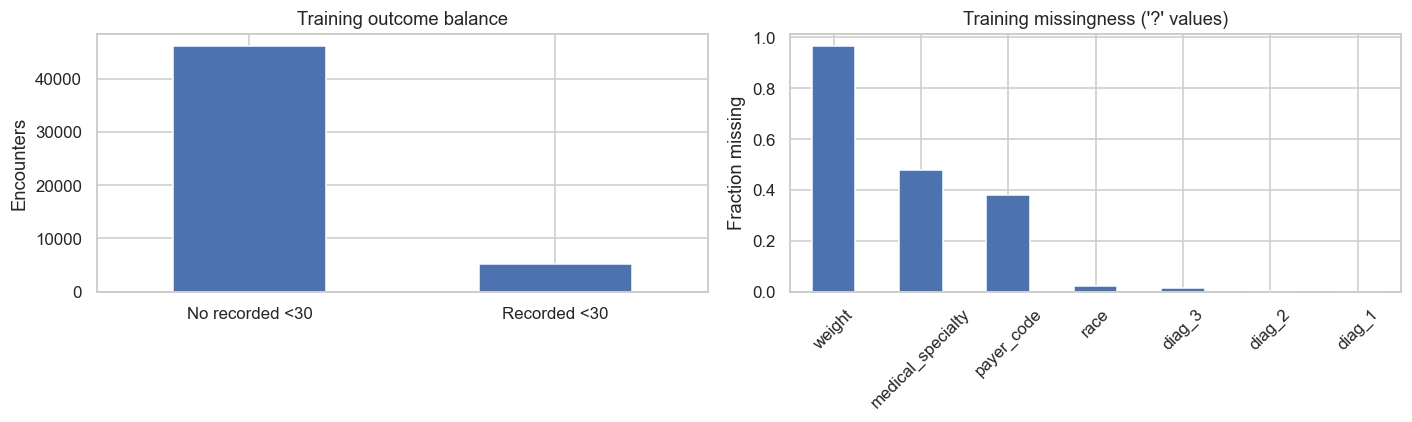

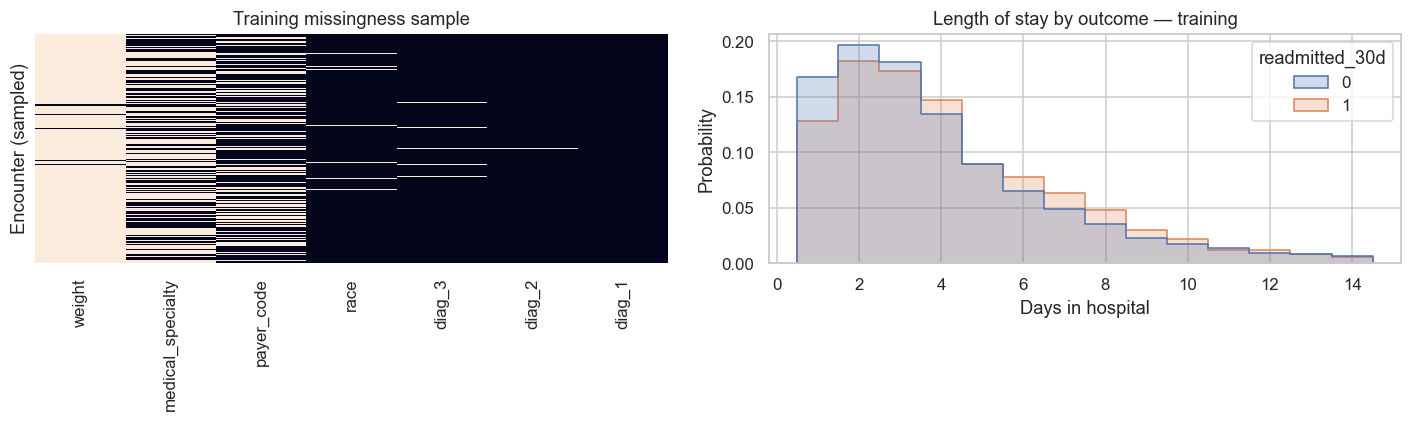

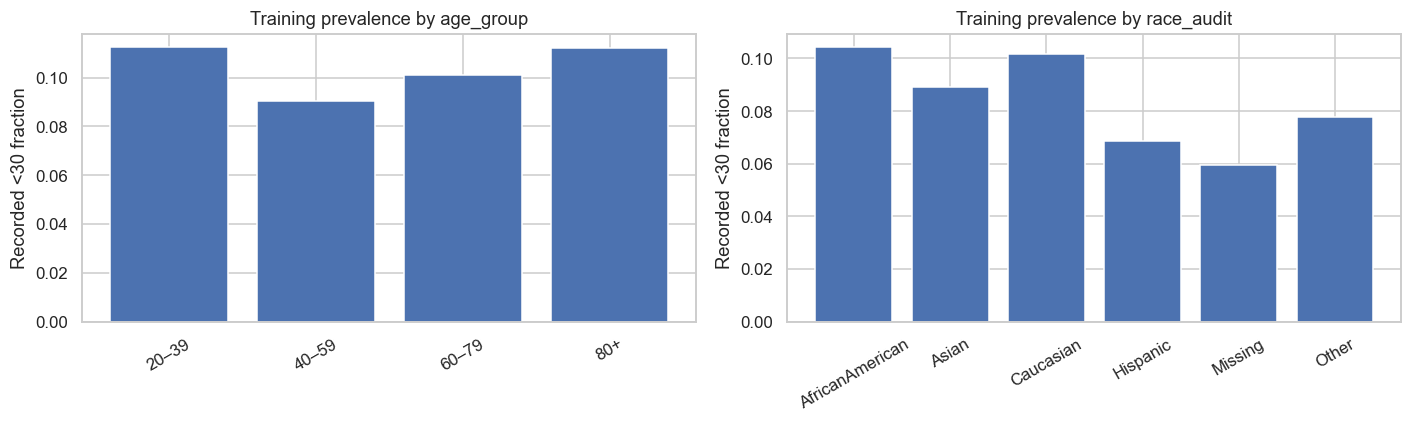

**So what?** Training contains **51,253 encounters** from **38,249 patients**, with **5,133 early readmissions (10.0%)**. Predicting 'no early readmission' for everyone would be **90.0% accurate** while finding no cases. HbA1c was recorded as not measured in **82.8%** of training encounters; this describes testing, not normal glycemic control. Weight is missing in **96.6%** and payer code in **37.9%**. Payer subgroup results must retain a missing category, and insurance is not a complete measure of socioeconomic status.

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")
for i, row in flow_table.iterrows():
    y = 0.94 - i * 0.20
    ax.text(0.5, y, f"{row['stage']}\n{row['encounters']:,} encounters / {row['patients']:,} patients"
            + (f" · removed {row['removed_encounters']:,}" if i else ""),
            ha="center", va="center", transform=ax.transAxes,
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "#e8eef5", "edgecolor": "#456789"})
    if i < len(flow_table) - 1:
        ax.annotate("", xy=(0.5, y-0.15), xytext=(0.5, y-0.06), xycoords="axes fraction",
                    arrowprops={"arrowstyle": "->"})
ax.set_title("Cohort flow — counts only; outcomes reserved by partition")
fig.savefig(ARTIFACT_DIR / "cohort_flow.png", bbox_inches="tight")
plt.show()

cohort_tables = []
for attribute in ["age_group", "gender_audit", "race_audit", "payer_code_audit"]:
    table = train_df.groupby(attribute, dropna=False).agg(
        encounters=(TARGET, "size"), patients=(PATIENT_ID, "nunique"),
        early_readmissions=(TARGET, "sum"), prevalence=(TARGET, "mean"))
    table["share_of_training"] = table["encounters"] / len(train_df)
    table = table.reset_index().rename(columns={attribute: "group"}).assign(attribute=attribute)
    cohort_tables.append(table)
training_cohort_table = pd.concat(cohort_tables, ignore_index=True)
display(training_cohort_table.round(4))
training_cohort_table.to_csv(ARTIFACT_DIR / "training_cohort_table.csv", index=False)
display(train_df[["time_in_hospital", "number_inpatient", "number_emergency", "num_medications"]]
        .describe(percentiles=[0.25, 0.5, 0.75]).round(2))

missingness = train_df[raw.columns].isna().mean().sort_values(ascending=False)
display(missingness[missingness > 0].rename("missing_fraction").to_frame())
missingness.rename("missing_fraction").to_csv(ARTIFACT_DIR / "training_missingness.csv")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train_df[TARGET].map({0: "No recorded <30", 1: "Recorded <30"}).value_counts().plot.bar(ax=axes[0], rot=0)
axes[0].set(title="Training outcome balance", ylabel="Encounters", xlabel="")
missingness[missingness > 0].plot.bar(ax=axes[1], rot=45)
axes[1].set(title="Training missingness ('?' values)", ylabel="Fraction missing")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "training_balance_missingness.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
missing_columns = missingness[missingness > 0].index
sns.heatmap(train_df.sample(n=min(400, len(train_df)), random_state=RANDOM_STATE)[missing_columns].isna(),
            cbar=False, yticklabels=False, ax=axes[0])
axes[0].set(title="Training missingness sample", ylabel="Encounter (sampled)")
sns.histplot(data=train_df, x="time_in_hospital", hue=TARGET, discrete=True,
             stat="probability", common_norm=False, element="step", ax=axes[1])
axes[1].set(title="Length of stay by outcome — training", xlabel="Days in hospital")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "training_feature_distributions.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, attribute in zip(axes, ["age_group", "race_audit"]):
    subset = training_cohort_table.query("attribute == @attribute")
    ax.bar(subset["group"], subset["prevalence"])
    ax.tick_params(axis="x", rotation=30)
    ax.set(title=f"Training prevalence by {attribute}", ylabel="Recorded <30 fraction")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "training_subgroup_prevalence.png", bbox_inches="tight")
plt.show()

training_prevalence = train_df[TARGET].mean()
display(Markdown(
    f"**So what?** Training contains **{len(train_df):,} encounters** from **{train_df[PATIENT_ID].nunique():,} patients**, "
    f"with **{train_df[TARGET].sum():,} early readmissions ({training_prevalence:.1%})**. "
    f"Predicting 'no early readmission' for everyone would be **{1-training_prevalence:.1%} accurate** while finding no cases. "
    f"HbA1c was recorded as not measured in **{train_df['A1Cresult'].eq('None').mean():.1%}** of training encounters; "
    "this describes testing, not normal glycemic control. "
    f"Weight is missing in **{train_df['weight'].isna().mean():.1%}** and payer code in **{train_df['payer_code'].isna().mean():.1%}**. "
    "Payer subgroup results must retain a missing category, and insurance is not a complete measure of socioeconomic status."
))


**Representativeness and label limitations:** These are selected 1999–2008 diabetes-coded encounters from institutions contributing to one EHR warehouse, not a random national sample. Out-of-network readmissions are absent; `NO` is no recorded readmission, not guaranteed absence of all readmission. The public labels do not separately identify preventable/unplanned events or resolve the exact day-30 boundary. The study excludes stays outside 1–14 days and our outpatient eligibility further excludes facility care and uncertain destinations. Results cannot establish generalization to modern hospitals or Spain. Repeated encounters are correlated and represent an encounter-weighted workload question; frequent users contribute more observations.


## 3. Experimental design and splits 

Patients were assigned **before training EDA** using nested `GroupShuffleSplit` with seed 42, in encounter-ID sorted input order. IDs are grouping keys, not predictors or timestamps. Membership is saved in `artifacts/split_manifest.csv`; no resampling is applied.

| Partition | Intended patient share | Permitted use |
|---|---:|---|
| Train | 70% | EDA, feature rationale, preprocessing, model fitting |
| Calibration validation | 7.5% | Group later fits calibration only |
| Policy validation | 7.5% | Prespecified model discrimination now; threshold selection later |
| Final test | 15% | One evaluation after full model and threshold lock |

**Advantage:** Calibration fitting and policy selection use **different patients**. No model tuning follows policy-validation results in this first half; this avoids repeatedly optimizing to the evaluation set. If model selection is later introduced, use patient-group-aware CV within training data, not either holdout. Final-test labels are retained in memory as part of the partition but are not summarized, scored, or used for decisions.

These splits are not stratified; encounter proportions and prevalence can differ. No favorable seed was selected. The public CSV lacks suitable date/hospital identifiers for genuine temporal/site splits; this evaluates held-out patients within the same historical source, not future deployment.


In [42]:
split_summary = pd.DataFrame([
    {"partition": name, "encounters": len(frame), "patients": frame[PATIENT_ID].nunique(),
     "patient_fraction": frame[PATIENT_ID].nunique() / cohort[PATIENT_ID].nunique()}
    for name, frame in partitions.items()
])
display(split_summary.round(4))
split_summary.to_csv(ARTIFACT_DIR / "split_sizes.csv", index=False)
display(Markdown("**So what?** All six pairwise patient-overlap checks passed. "
                 "A patient cannot appear on both sides of an evaluation, even when they have multiple admissions. "
                 "Calibration and policy data remain distinct; no final-test performance has been computed."))


,partition,encounters,patients,patient_fraction
0,train,51253,38249,0.700
1,calibration,5422,4098,0.075
2,policy,5552,4098,0.075
3,test,10864,8197,0.150


**So what?** All six pairwise patient-overlap checks passed. A patient cannot appear on both sides of an evaluation, even when they have multiple admissions. Calibration and policy data remain distinct; no final-test performance has been computed.

## 4. Pipelines, baselines and leakage controls

**Prespecified model:** Unweighted L2 logistic regression, `C=1`, `lbfgs`, maximum 2,000 iterations. No hyperparameter search, feature selection by holdout performance, synthetic balancing, or interactions. This provides an interpretable initial benchmark rather than a claim of optimal prediction.

Eight numeric features describe utilization and the index encounter; nine categorical features cover demographics, admission context, HbA1c testing, and treatment. Race/gender are included in this research benchmark for transparent audit, not asserted to be biologic causes or approved deployment inputs. Payer is retained **for auditing only**. Missing payer/weight and high-cardinality diagnosis/specialty features are not added opportunistically. The dictionary below documents every model input and principal exclusions.

Numeric imputation/scaling and categorical imputation/encoding are fitted inside the training-only pipeline. Literal not-tested/not-prescribed categories remain categories; integer-coded admission fields are strings, not continuous quantities. Missing race remains missing in the audit even when the model imputes it.


In [43]:
numeric_features = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
                    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]
categorical_features = ["age", "race", "gender", "admission_type_id", "admission_source_id",
                        "A1Cresult", "insulin", "change", "diabetesMed"]
feature_columns = numeric_features + categorical_features
feature_meanings = {
    "time_in_hospital": "Index stay duration, 1–14 days",
    "num_lab_procedures": "Laboratory tests during index encounter",
    "num_procedures": "Non-laboratory procedures during index encounter",
    "num_medications": "Distinct generic medications administered during encounter",
    "number_outpatient": "Outpatient visits during preceding year",
    "number_emergency": "Emergency visits during preceding year (not six months)",
    "number_inpatient": "Inpatient visits during preceding year",
    "number_diagnoses": "Number of diagnoses entered for index encounter",
    "age": "Released 10-year age band; encoded categorically",
    "race": "Recorded race category; potential proxy and audit attribute",
    "gender": "Recorded gender category; audit attribute",
    "admission_type_id": "Admission context, e.g. emergency/elective; nominal code",
    "admission_source_id": "Referral/transfer source; nominal code",
    "A1Cresult": "HbA1c result band; None = not measured, not normal",
    "insulin": "No/Steady/Up/Down during encounter, not home adherence",
    "change": "Any recorded change in diabetes medication during encounter",
    "diabetesMed": "Any diabetes medication prescribed during encounter",
}
dictionary_rows = [{"feature": name, "role": "predictor", "type": "numeric" if name in numeric_features else "categorical",
                    "meaning": feature_meanings[name], "availability": "By discharge",
                    "missing_handling": "Training median" if name in numeric_features else "Training mode for ?; preserve literal categories"}
                   for name in feature_columns]
for name, role, reason in [
    (PATIENT_ID, "grouping only", "Keep patients disjoint; never input to model"),
    ("encounter_id", "manifest only", "Unique encounter; not a timestamp or predictor"),
    ("readmitted", "label only", "Source outcome; excluded from X"),
    (TARGET, "target only", "1 for <30; 0 otherwise"),
    ("payer_code", "audit only", "Insurance proxy; missingness retained in audit"),
    ("discharge_disposition_id", "eligibility only", "Defines follow-up pathway; excluded from X"),
    ("weight", "excluded", "Sparse measurement; not required by prespecified model"),
    ("medical_specialty", "excluded", "High-cardinality practice information; omitted for initial benchmark"),
    ("diag_1 / diag_2 / diag_3", "excluded", "Limited diagnosis extract; no new diabetes filter or code-based feature search"),
]:
    dictionary_rows.append({"feature": name, "role": role, "type": "see source", "meaning": reason,
                            "availability": "Outcome after discharge" if role in ["target only", "label only"] else "By discharge",
                            "missing_handling": "Not part of model"})
feature_dictionary = pd.DataFrame(dictionary_rows)
display(feature_dictionary)
feature_dictionary.to_csv(ARTIFACT_DIR / "feature_dictionary.csv", index=False)

# Fixed semantic conversion, not a learned transformation; preserve true NaNs.
for frame in partitions.values():
    for col in categorical_features:
        frame[col] = frame[col].map(lambda value: str(value) if pd.notna(value) else np.nan).astype(object)
assert not {TARGET, "readmitted", PATIENT_ID, "encounter_id"} & set(feature_columns)

numeric_pipeline = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])
model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE)),
])
X_train, y_train = train_df[feature_columns], train_df[TARGET]
X_cal, y_cal = calibration_df[feature_columns], calibration_df[TARGET]
X_policy, y_policy = policy_df[feature_columns], policy_df[TARGET]
assert y_train.nunique() == y_policy.nunique() == 2
baseline = DummyClassifier(strategy="prior").fit(X_train, y_train)
with warnings.catch_warnings():
    warnings.simplefilter("error", ConvergenceWarning)
    model.fit(X_train, y_train)
assert np.isfinite(model.predict_proba(X_train.iloc[:10])).all()
display(model)
print("Converged iterations:", model.named_steps["classifier"].n_iter_.tolist())
print("Encoded feature count:", len(model.named_steps["preprocess"].get_feature_names_out()))
joblib.dump(model, ARTIFACT_DIR / "uncalibrated_logistic.joblib")
joblib.dump(baseline, ARTIFACT_DIR / "prevalence_baseline.joblib")


,feature,role,type,meaning,availability,missing_handling
0,time_in_hospital,predictor,numeric,"Index stay duration, 1–14 days",By discharge,Training median
1,num_lab_procedures,predictor,numeric,Laboratory tests during index encounter,By discharge,Training median
2,num_procedures,predictor,numeric,Non-laboratory procedures during index encounter,By discharge,Training median
3,num_medications,predictor,numeric,Distinct generic medications administered duri...,By discharge,Training median
4,number_outpatient,predictor,numeric,Outpatient visits during preceding year,By discharge,Training median
5,number_emergency,predictor,numeric,Emergency visits during preceding year (not si...,By discharge,Training median
6,number_inpatient,predictor,numeric,Inpatient visits during preceding year,By discharge,Training median
7,number_diagnoses,predictor,numeric,Number of diagnoses entered for index encounter,By discharge,Training median
8,age,predictor,categorical,Released 10-year age band; encoded categorically,By discharge,Training mode for ?; preserve literal categories
9,race,predictor,categorical,Recorded race category; potential proxy and au...,By discharge,Training mode for ?; preserve literal categories


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses']),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age', 'race', 'gender',
                                                   'admission_type_id',
                                                   'admission_source_id',
                                                   'A1Cresult', 'insulin',
                                                   'change',
                                                   'diabetesMed'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

Converged iterations: [27]
Encoded feature count: 61


['artifacts/prevalence_baseline.joblib']

**So what?** The baseline asks whether patient-level information helps more than knowing the training readmission rate. Logistic regression can assign different risks but does not demonstrate causation, treatment benefit, or performance superior to clinicians. All encounter summaries are appropriate only for the discharge-time question. A later admission-time model would require different inputs and a new design. Calibration is deliberately not fitted yet.


## 5. Metrics and discrimination analysis

**Primary metric:** Average precision (AP), compared with policy-set prevalence. AP is not trapezoidal PR AUC. ROC AUC complements AP; accuracy alone would reward predicting the majority class. No decision threshold is selected or evaluated here.

**Uncertainty:** 300 deterministic patient-cluster bootstrap replicates, sampling patients with replacement and carrying all their evaluation encounters together. Percentile 95% intervals condition on the fitted model; they do not include model-training uncertainty. The baseline and model use the same draws for paired metric differences. Single-class replicates are excluded with the valid count reported; a point metric is undefined for single-class groups. These exploratory intervals are not multiplicity-adjusted.

**Subgroups fixed before seeing results:** Age 20–39/40–59/60–79/80+, recorded gender, recorded race, and each payer category including missing. Small groups remain visible. Fewer than 20 distinct patients contributing positive encounters or 20 contributing negative encounters is a caution flag, not a statistical reliability guarantee. A patient may contribute both outcomes, so these patient counts can overlap. Encounter counts remain the workload denominator; bootstrap resampling remains patient-level. Subgroup AP depends on prevalence, so raw AP gaps do not establish unfairness or its cause.


,model,AP,AP_low,AP_high,ROC_AUC,ROC_low,ROC_high,valid_bootstraps
0,Prevalence baseline,0.1110,0.1004,0.1228,0.5000,0.5000,0.5000,300
1,Logistic regression,0.2500,0.1966,0.3009,0.6715,0.6385,0.7008,300
2,Logistic minus baseline,0.1391,0.0951,0.1824,0.1715,0.1385,0.2008,300


Policy validation: 5,552 encounters; 616 positives; prevalence 11.10%


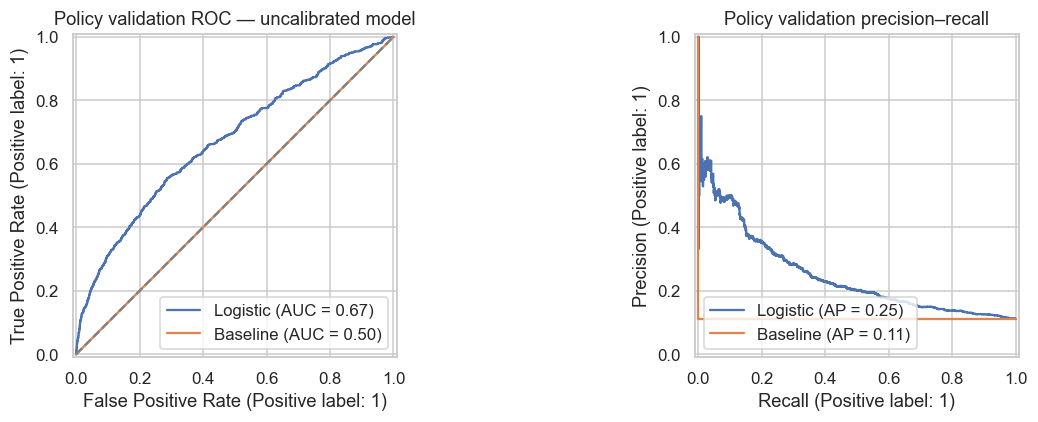

In [44]:
def discrimination_metrics(y, scores):
    y, scores = np.asarray(y), np.asarray(scores)
    if np.unique(y).size < 2:
        return np.array([np.nan, np.nan])
    return np.array([average_precision_score(y, scores), roc_auc_score(y, scores)])

def cluster_metric_intervals(y, scores, patient_ids, comparison=None):
    """Encounter-weighted metrics; patient-level resampling preserves repeat visits."""
    y, scores = np.asarray(y), np.asarray(scores)
    point = discrimination_metrics(y, scores)
    if comparison is not None:
        comparison = np.asarray(comparison)
        point = point - discrimination_metrics(y, comparison)
    if np.unique(y).size < 2:
        return point, np.full(2, np.nan), np.full(2, np.nan), 0
    _, group_index = np.unique(np.asarray(patient_ids), return_inverse=True)
    members = [np.flatnonzero(group_index == k) for k in range(group_index.max() + 1)]
    rng = np.random.default_rng(RANDOM_STATE)
    draws = []
    for _ in range(N_BOOTSTRAP):
        index = np.concatenate([members[k] for k in rng.integers(0, len(members), size=len(members))])
        values = discrimination_metrics(y[index], scores[index])
        if comparison is not None:
            values -= discrimination_metrics(y[index], comparison[index])
        if np.isfinite(values).all():
            draws.append(values)
    if not draws:
        return point, np.full(2, np.nan), np.full(2, np.nan), 0
    low, high = np.quantile(draws, [0.025, 0.975], axis=0)
    return point, low, high, len(draws)

p_policy_raw = model.predict_proba(X_policy)[:, list(model.classes_).index(1)]
p_policy_baseline = baseline.predict_proba(X_policy)[:, list(baseline.classes_).index(1)]
metric_rows = []
for name, scores, comparator in [
    ("Prevalence baseline", p_policy_baseline, None),
    ("Logistic regression", p_policy_raw, None),
    ("Logistic minus baseline", p_policy_raw, p_policy_baseline),
]:
    point, low, high, valid = cluster_metric_intervals(y_policy, scores, policy_df[PATIENT_ID], comparator)
    metric_rows.append({"model": name, "AP": point[0], "AP_low": low[0], "AP_high": high[0],
                        "ROC_AUC": point[1], "ROC_low": low[1], "ROC_high": high[1], "valid_bootstraps": valid})
metrics_table = pd.DataFrame(metric_rows)
display(metrics_table.round(4))
metrics_table.to_csv(ARTIFACT_DIR / "policy_discrimination.csv", index=False)
print(f"Policy validation: {len(y_policy):,} encounters; {y_policy.sum():,} positives; prevalence {y_policy.mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, scores in [("Logistic", p_policy_raw), ("Baseline", p_policy_baseline)]:
    RocCurveDisplay.from_predictions(y_policy, scores, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_policy, scores, name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("Policy validation ROC — uncalibrated model")
axes[1].set_title("Policy validation precision–recall")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "policy_roc_pr.png", bbox_inches="tight")
plt.show()


,attribute,group,encounters,patients,positives,positive_patients,negative_patients,prevalence,AP,AP_low,AP_high,ROC_AUC,ROC_low,ROC_high,valid_bootstraps,caution
0,age_group,20–39,345,250,42,28,244,0.1217,0.2506,0.1244,0.4223,0.6697,0.5654,0.7465,300,
1,age_group,40–59,1754,1272,203,128,1240,0.1157,0.3211,0.2251,0.4085,0.7314,0.6741,0.7743,300,
2,age_group,60–79,2698,2047,290,237,1941,0.1075,0.2449,0.1809,0.3190,0.6599,0.6152,0.6999,300,
3,age_group,80+,755,575,81,71,540,0.1073,0.1395,0.1023,0.1883,0.5717,0.5028,0.6360,300,
4,gender_audit,Female,2879,2104,330,228,2026,0.1146,0.2893,0.2157,0.3554,0.6980,0.6522,0.7358,300,
5,gender_audit,Male,2673,1995,286,235,1896,0.1070,0.2021,0.1672,0.2535,0.6401,0.6043,0.6800,300,
6,race_audit,AfricanAmerican,1111,769,127,79,750,0.1143,0.3258,0.1815,0.4333,0.7386,0.6613,0.7883,300,
7,race_audit,Asian,30,26,1,1,25,0.0333,0.0370,0.0294,0.1386,0.1034,0.0000,0.2435,187,Small / single-class patient support
8,race_audit,Caucasian,4058,3020,449,352,2877,0.1106,0.2307,0.1867,0.2822,0.6582,0.6224,0.6888,300,
9,race_audit,Hispanic,141,102,21,13,99,0.1489,0.4301,0.1102,0.6341,0.7901,0.5914,0.8880,300,Small / single-class patient support


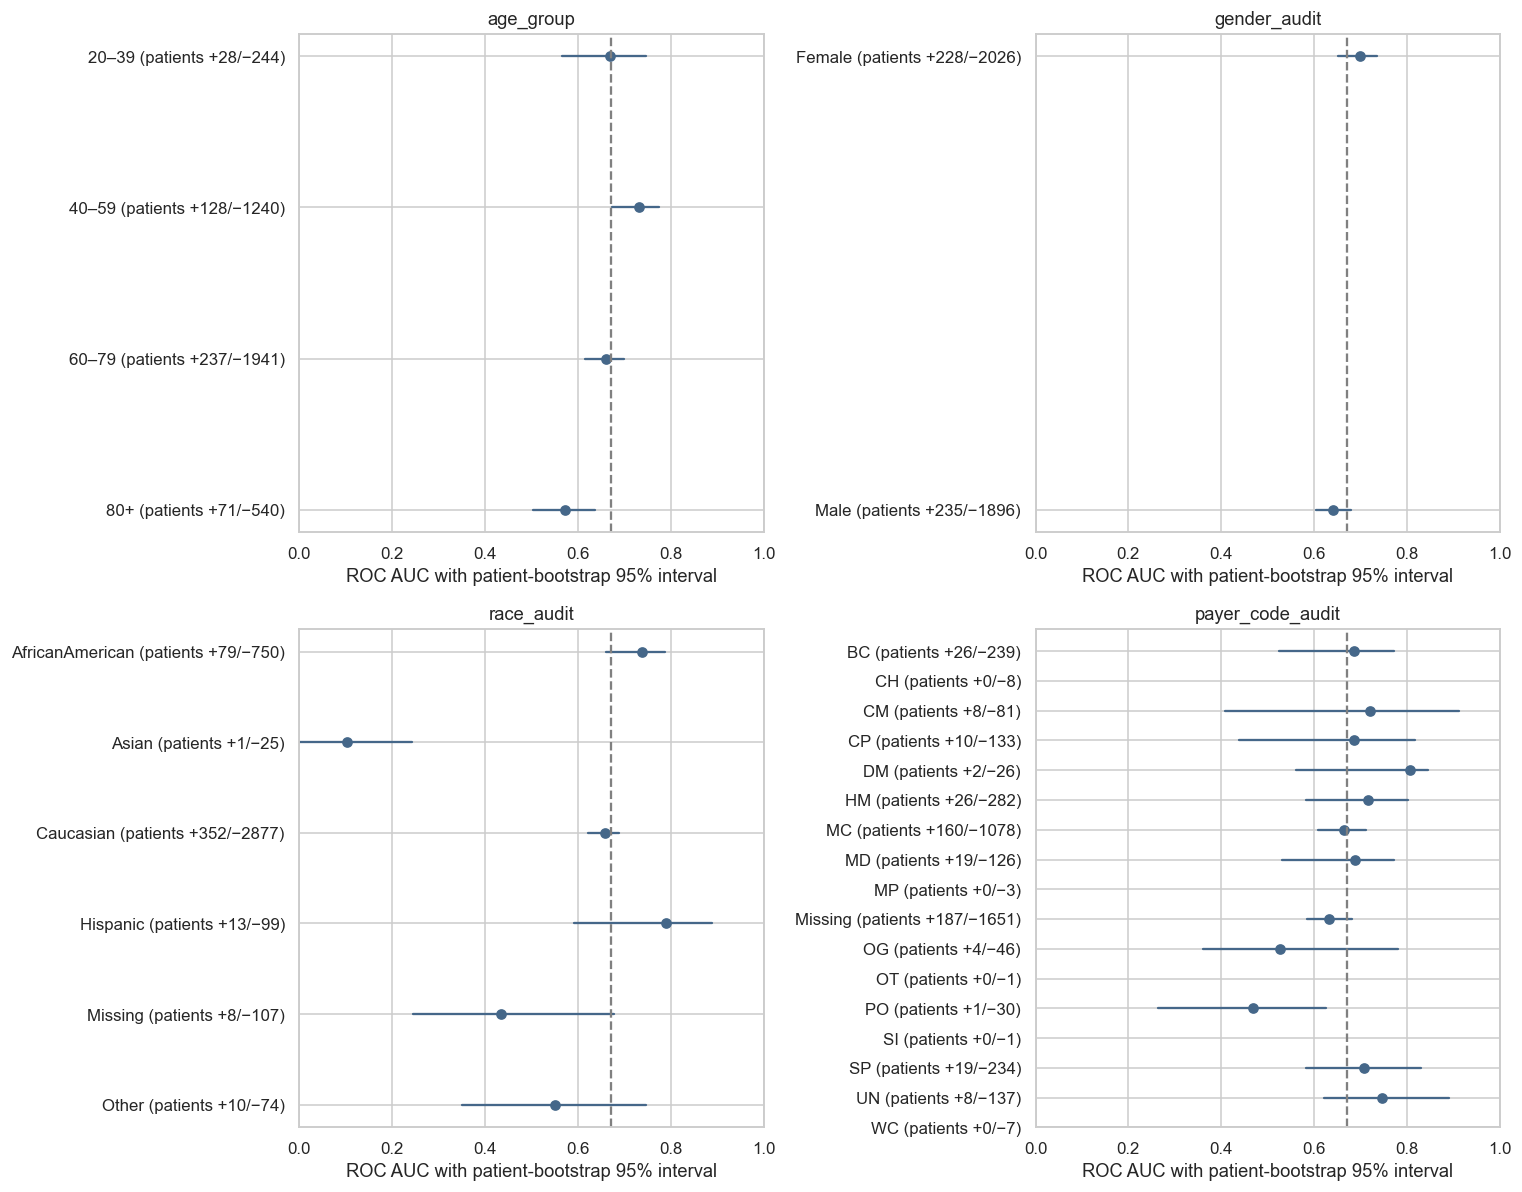

**So what?** On policy validation, logistic regression has AP **0.250** versus prevalence **0.111**, and ROC AUC **0.672** (95% interval **0.638–0.701**). The paired AP difference is **0.139** (95% interval **0.095–0.182**). These are ranking results, not proof of reliable probabilities or a useful contact policy. **17 subgroup rows** have fewer than 20 distinct patients contributing positive or negative encounters and must not support firm disparity claims. No model changes were made in response to these validation results.

,attribute,group,encounters,positives,patients,positive_patients,negative_patients,caution
7,race_audit,Asian,30,1,26,1,25,Small / single-class patient support
9,race_audit,Hispanic,141,21,102,13,99,Small / single-class patient support
10,race_audit,Missing,117,8,112,8,107,Small / single-class patient support
11,race_audit,Other,95,10,81,10,74,Small / single-class patient support
13,payer_code_audit,CH,8,0,8,0,8,Small / single-class patient support
14,payer_code_audit,CM,109,10,83,8,81,Small / single-class patient support
15,payer_code_audit,CP,163,14,138,10,133,Small / single-class patient support
16,payer_code_audit,DM,55,13,27,2,26,Small / single-class patient support
19,payer_code_audit,MD,196,27,131,19,126,Small / single-class patient support
20,payer_code_audit,MP,3,0,3,0,3,Small / single-class patient support


In [45]:
audit_columns = ["age_group", "gender_audit", "race_audit", "payer_code_audit"]
audit = policy_df[[PATIENT_ID, TARGET] + audit_columns].copy()
audit["score"] = p_policy_raw
subgroup_rows = []
for attribute in audit_columns:
    for group, frame in audit.groupby(attribute, dropna=False, sort=True):
        point, low, high, valid = cluster_metric_intervals(frame[TARGET], frame["score"], frame[PATIENT_ID])
        positives = int(frame[TARGET].sum())
        positive_patients = frame.loc[frame[TARGET].eq(1), PATIENT_ID].nunique()
        negative_patients = frame.loc[frame[TARGET].eq(0), PATIENT_ID].nunique()
        subgroup_rows.append({
            "attribute": attribute, "group": group, "encounters": len(frame),
            "patients": frame[PATIENT_ID].nunique(), "positives": positives,
            "positive_patients": positive_patients, "negative_patients": negative_patients,
            "prevalence": frame[TARGET].mean(), "AP": point[0], "AP_low": low[0], "AP_high": high[0],
            "ROC_AUC": point[1], "ROC_low": low[1], "ROC_high": high[1],
            "valid_bootstraps": valid,
            "caution": "Small / single-class patient support" if min(positive_patients, negative_patients) < 20 else "",
        })
subgroup_metrics = pd.DataFrame(subgroup_rows)
display(subgroup_metrics.round(4))
subgroup_metrics.to_csv(ARTIFACT_DIR / "policy_subgroup_discrimination.csv", index=False)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
overall_auc = metrics_table.loc[metrics_table["model"].eq("Logistic regression"), "ROC_AUC"].iloc[0]
for ax, attribute in zip(axes.ravel(), audit_columns):
    rows = subgroup_metrics.loc[subgroup_metrics["attribute"].eq(attribute)].reset_index(drop=True)
    for i, row in rows.iterrows():
        if pd.notna(row["ROC_AUC"]):
            ax.plot([row["ROC_low"], row["ROC_high"]], [i, i], color="#456789")
            ax.plot(row["ROC_AUC"], i, "o", color="#456789")
    ax.axvline(overall_auc, color="gray", linestyle="--", label="Overall ROC AUC")
    ax.set_yticks(range(len(rows)), [f"{r['group']} (patients +{r['positive_patients']}/−{r['negative_patients']})" for _, r in rows.iterrows()])
    ax.set(xlabel="ROC AUC with patient-bootstrap 95% interval", title=attribute, xlim=(0, 1))
    ax.invert_yaxis()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "policy_subgroup_auc.png", bbox_inches="tight")
plt.show()

logistic_row = metrics_table.loc[metrics_table["model"].eq("Logistic regression")].iloc[0]
difference_row = metrics_table.loc[metrics_table["model"].eq("Logistic minus baseline")].iloc[0]
small_rows = subgroup_metrics.loc[subgroup_metrics["caution"].ne("")]
display(Markdown(
    f"**So what?** On policy validation, logistic regression has AP **{logistic_row['AP']:.3f}** "
    f"versus prevalence **{y_policy.mean():.3f}**, and ROC AUC **{logistic_row['ROC_AUC']:.3f}** "
    f"(95% interval **{logistic_row['ROC_low']:.3f}–{logistic_row['ROC_high']:.3f}**). "
    f"The paired AP difference is **{difference_row['AP']:.3f}** "
    f"(95% interval **{difference_row['AP_low']:.3f}–{difference_row['AP_high']:.3f}**). "
    "These are ranking results, not proof of reliable probabilities or a useful contact policy. "
    f"**{len(small_rows)} subgroup rows** have fewer than 20 distinct patients contributing positive or negative encounters and must not support firm disparity claims. "
    "No model changes were made in response to these validation results."
))
if len(small_rows):
    display(small_rows[["attribute", "group", "encounters", "positives", "patients",
                        "positive_patients", "negative_patients", "caution"]])


## Group handoff — first half ends here

**Completed inputs in memory:** `train_df`, `calibration_df`, `policy_df`, `test_df`; `X_train/y_train`, `X_cal/y_cal`, `X_policy/y_policy`; `feature_columns`, `numeric_features`, `categorical_features`; fitted uncalibrated `model` and `baseline`; `p_policy_raw`, `p_policy_baseline`; overall/subgroup development tables. `cluster_metric_intervals` supplies patient-cluster intervals for AP/ROC AUC.

**Reproduction:** Run this first half to recreate exact cohort, transformations, and partitions; use the saved manifest to audit assignment. `artifacts/uncalibrated_logistic.joblib` is a convenience model artifact for the same pinned environment. Load joblib files only from trusted sources. The original CSVs are included in `Data/`; generated artifacts remain local/ignored. The notebook includes outputs, and rerunning regenerates the artifacts.

| Group responsibility | Contract |
|---|---|
| Step 6 — calibration | Fit calibration on `X_cal/y_cal` only; keep base model frozen. In sklearn 1.5.1 use the documented prefit calibration API. Evaluate on policy data. |
| Step 7 — thresholds | Select from policy data only; compare workload and recall constraints, including the 200/250 contact scenarios. 85% recall and 40% precision are aspirations, not results. |
| Step 8 — test | Lock full model, calibrator, features and threshold before first test predictions. Do not select a new policy to improve test results. |
| Step 9 — RAI | Test compatibility on development data; set up model/input representation and threshold semantics explicitly. Dashboard libraries are not installed or verified by this first-half run. |
| Presentation | Use saved plots and actual findings; distinguish ranking, calibration, policy impact, and causal claims. |

**Still intentionally unexecuted:** Calibration, decision thresholds, Brier/calibration analysis, final-test metrics, counterfactuals, causal analysis, RAI dashboard. Comments/templates below are assignments, not completed analysis. The existing environment aligns the scientific stack with the reference but does not claim end-to-end RAI compatibility.


In [46]:
handoff = {
    "completed_steps": [1, 2, 3, 4, 5], "remaining_steps": [6, 7, 8, 9],
    "target": TARGET, "positive_label": "readmitted == <30", "prediction_time": "discharge",
    "random_state": RANDOM_STATE, "minimum_age": 20,
    "eligible_discharge_codes": sorted(HOME_OUTPATIENT_CODES),
    "numeric_features": numeric_features, "categorical_features": categorical_features,
    "audit_columns": audit_columns, "test_evaluated": False, "calibration_fitted": False,
    "threshold_selected": False, "data_sha256": actual_hashes,
    "split_manifest_sha256": hashlib.sha256((ARTIFACT_DIR / "split_manifest.csv").read_bytes()).hexdigest(),
    "policy_aspirations": {"recall": RECALL_FLOOR, "precision": PRECISION_ASPIRATION,
                           "contacts_per_1000": [ALERT_BUDGET_PER_1000, ALTERNATIVE_ALERT_BUDGET_PER_1000]},
}
(ARTIFACT_DIR / "handoff.json").write_text(json.dumps(handoff, indent=2) + "\n")
# Contract checks: no calibration, threshold, or final-test predictions have been created.
# assert all(name not in globals() for name in ["calibrated_model", "locked_threshold", "p_test", "y_test_pred"])
print("First half complete. Calibration, threshold selection, and final-test evaluation remain unexecuted.")


First half complete. Calibration, threshold selection, and final-test evaluation remain unexecuted.


## 6. Probability calibration and uncertainty — 8%

**Goal:** A score of 0.20 should correspond approximately to a 20% recorded-readmission rate among comparable scored encounters—not a guarantee for an individual.

**Complete:** Freeze the fitted training model, fit a sigmoid calibrator on `X_cal, y_cal` only, then assess raw versus calibrated scores on `X_policy, y_policy`. Do not refit the base model on calibration data or calibrate on test.

**Version-sensitive implementation:** Use the supported prefit/frozen-estimator calibration API for the pinned scikit-learn version. In the reference's 1.5.1 environment, this is `CalibratedClassifierCV(model, method="sigmoid", cv="prefit")`; newer versions offer `FrozenEstimator`. Verify the actual environment before choosing the API.

**Outputs:** Reliability plots; Brier score; mean predicted probability versus observed prevalence; uncertainty intervals. Use patient-cluster bootstrap resampling when calculating intervals because encounters from one patient are correlated. Do not interpret Brier score alone as a pure measure of calibration.


In [47]:
# STARTER TEMPLATE — uncomment when completing this section.
# # Complete: create `calibrated_model` using the version-appropriate frozen API,
# # then fit ONLY on X_cal, y_cal.
#
# p_policy = calibrated_model.predict_proba(X_policy)[
#     :, list(calibrated_model.classes_).index(1)
# ]
# for name, scores in [("Raw", p_policy_raw), ("Calibrated", p_policy)]:
#     print(name, {
#         "brier": brier_score_loss(y_policy, scores),
#         "mean_probability": scores.mean(),
#         "observed_prevalence": y_policy.mean(),
#     })
#     CalibrationDisplay.from_predictions(y_policy, scores, n_bins=10, name=name)
# plt.show()
# # Complete: uncertainty method, patient-cluster resampling, and subgroup calibration.


### 6.1 Fitting the calibrator

In [48]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss
import sklearn

_sk_ver = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
if _sk_ver >= (1, 6):
    from sklearn.frozen import FrozenEstimator
    calibrated_model = CalibratedClassifierCV(FrozenEstimator(model), method="sigmoid")
else:
    calibrated_model = CalibratedClassifierCV(model, method="sigmoid", cv="prefit")

calibrated_model.fit(X_cal, y_cal)
joblib.dump(calibrated_model, ARTIFACT_DIR / "calibrated_model.joblib")

['artifacts/calibrated_model.joblib']

### 6.2. Calibration-in-the-Large, Risk Bands and Reliability Plot

Observed readmission prevalence,Mean raw predicted probability,Mean calibrated predicted probability,Absolute difference (calibrated vs observed)
0.111,0.102,0.100,0.011


"Risk band (Q1 = lowest, Q10 = highest)",Records in band,Mean raw predicted probability,Observed readmission rate,Mean calibrated predicted probability
Q1,556,0.052000,0.049000,0.047000
Q2,555,0.063000,0.059000,0.059000
Q3,555,0.070000,0.070000,0.066000
Q4,555,0.077000,0.077000,0.072000
Q5,555,0.084000,0.088000,0.080000
Q6,555,0.091000,0.076000,0.087000
Q7,555,0.099000,0.103000,0.096000
Q8,555,0.111000,0.135000,0.108000
Q9,555,0.133000,0.153000,0.131000
Q10,556,0.243000,0.299000,0.251000


Risk-band table includes 5552 of 5552 policy validation records


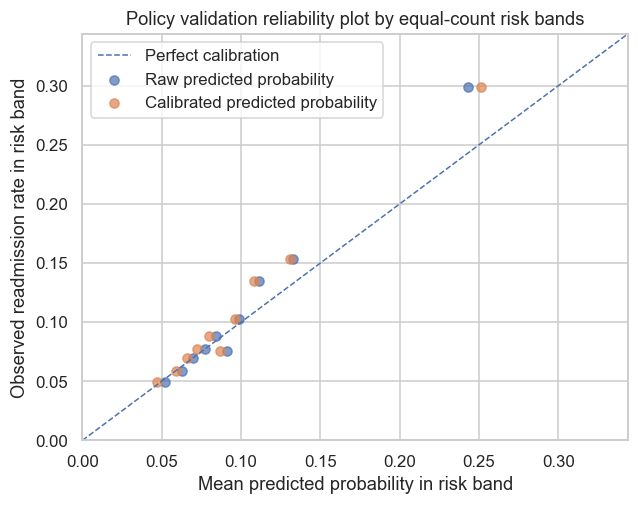

In [49]:
p_before = p_policy_raw
p_after  = calibrated_model.predict_proba(X_policy)[
    :, list(calibrated_model.classes_).index(1)
]

df_cal = pd.DataFrame({
    "Readmitted_30d": y_policy.values,
    "Pred_before":    p_before,
    "Pred_after":     p_after,
}, index=X_policy.index)

calibration_in_the_large_table = pd.DataFrame([{
    "Observed readmission prevalence":              float(df_cal["Readmitted_30d"].mean()),
    "Mean raw predicted probability":               float(df_cal["Pred_before"].mean()),
    "Mean calibrated predicted probability":        float(df_cal["Pred_after"].mean()),
    "Absolute difference (calibrated vs observed)": abs(df_cal["Pred_after"].mean() - df_cal["Readmitted_30d"].mean()),
}])
display(
    calibration_in_the_large_table.style
    .hide(axis="index")
    .format({col: "{:.3f}" for col in calibration_in_the_large_table.columns})
)

df_cal["Risk_band"] = pd.qcut(
    df_cal["Pred_after"], q=10,
    labels=[f"Q{i}" for i in range(1, 11)],
    duplicates="drop",
)

calibration_summary = (
    df_cal.groupby("Risk_band", observed=True)
    .agg(
        Records        = ("Readmitted_30d", "size"),
        Avg_pred_before= ("Pred_before", "mean"),
        Observed_rate  = ("Readmitted_30d", "mean"),
        Avg_pred_after = ("Pred_after", "mean"),
    )
    .reset_index()
    .round(3)
)
display(
    calibration_summary.rename(columns={
        "Risk_band":         "Risk band (Q1 = lowest, Q10 = highest)",
        "Records":           "Records in band",
        "Avg_pred_before":   "Mean raw predicted probability",
        "Observed_rate":     "Observed readmission rate",
        "Avg_pred_after":    "Mean calibrated predicted probability",
    })
    .style
    .hide(axis="index")
)
print(f"Risk-band table includes {int(calibration_summary['Records'].sum())} of {len(X_policy)} policy validation records")

upper = max(
    calibration_summary["Avg_pred_after"].max(),
    calibration_summary["Observed_rate"].max(),
) * 1.15

plt.figure()
plt.plot([0, upper], [0, upper], linestyle="--", linewidth=1, label="Perfect calibration")
plt.scatter(
    calibration_summary["Avg_pred_before"],
    calibration_summary["Observed_rate"],
    label="Raw predicted probability",
    alpha=0.7,
)
plt.scatter(
    calibration_summary["Avg_pred_after"],
    calibration_summary["Observed_rate"],
    label="Calibrated predicted probability",
    alpha=0.7,
)
plt.xlim(0, upper)
plt.ylim(0, upper)
plt.xlabel("Mean predicted probability in risk band")
plt.ylabel("Observed readmission rate in risk band")
plt.title("Policy validation reliability plot by equal-count risk bands")
plt.legend()
plt.show()

### 6.3. Before vs After: Sample Encounter Table

In [50]:
sample_idx       = policy_df.sample(n=10, random_state=RANDOM_STATE).index.tolist()
sample_positions = [X_policy.index.get_loc(i) for i in sample_idx]

sample_table = pd.DataFrame({
    "Encounter ID":                    policy_df.loc[sample_idx, "encounter_id"].values,
    "Uncalibrated score":              p_before[sample_positions],
    "Alert before calibration (0.50)": (p_before[sample_positions] >= 0.50).astype(int),
    "Calibrated probability":          p_after[sample_positions],
    "Alert after calibration (0.50)":  (p_after[sample_positions] >= 0.50).astype(int),
    "Readmitted <30d":                 y_policy.values[sample_positions],
})
sample_table["Probability change"] = (
    sample_table["Calibrated probability"] - sample_table["Uncalibrated score"]
)
display(
    sample_table[[
        "Encounter ID", "Uncalibrated score", "Calibrated probability",
        "Probability change", "Alert before calibration (0.50)",
        "Alert after calibration (0.50)", "Readmitted <30d",
    ]]
    .style
    .hide(axis="index")
    .format({
        "Uncalibrated score":     "{:.3f}",
        "Calibrated probability": "{:.3f}",
        "Probability change":     "{:+.3f}",
    })
)

Encounter ID,Uncalibrated score,Calibrated probability,Probability change,Alert before calibration (0.50),Alert after calibration (0.50),Readmitted <30d
113546316,0.067,0.062,-0.005,0,0,0
207347610,0.175,0.176,+0.001,0,0,1
154749678,0.135,0.133,-0.002,0,0,0
24578280,0.084,0.080,-0.004,0,0,0
173971152,0.110,0.106,-0.003,0,0,0
158377902,0.125,0.123,-0.002,0,0,0
76820034,0.107,0.104,-0.003,0,0,0
116930154,0.061,0.056,-0.005,0,0,0
244184610,0.078,0.074,-0.005,0,0,0
33288012,0.172,0.173,+0.001,0,0,0


### 6.4. Discrimination and Probability Scoring Comparison

In [51]:
metrics_df = pd.DataFrame([
    {
        "Metric": "ROC AUC",
        "Uncalibrated": roc_auc_score(y_policy, p_before),
        "Calibrated":   roc_auc_score(y_policy, p_after),
        "Explanation":  "How well scores separate readmissions from non-readmissions across thresholds",
    },
    {
        "Metric": "Average precision",
        "Uncalibrated": average_precision_score(y_policy, p_before),
        "Calibrated":   average_precision_score(y_policy, p_after),
        "Explanation":  "Precision-recall summary; compare with observed prevalence",
    },
    {
        "Metric": "Log loss",
        "Uncalibrated": log_loss(y_policy, np.clip(p_before, 1e-6, 1-1e-6)),
        "Calibrated":   log_loss(y_policy, np.clip(p_after,  1e-6, 1-1e-6)),
        "Explanation":  "Penalizes wrong and overconfident probabilities; lower is better",
    },
    {
        "Metric": "Brier score",
        "Uncalibrated": brier_score_loss(y_policy, p_before),
        "Calibrated":   brier_score_loss(y_policy, p_after),
        "Explanation":  "Mean squared difference between predicted probability and outcome; lower is better",
    },
])
display(
    metrics_df.style
    .hide(axis="index")
    .format({"Uncalibrated": "{:.3f}", "Calibrated": "{:.3f}"})
)

Metric,Uncalibrated,Calibrated,Explanation
ROC AUC,0.672,0.672,How well scores separate readmissions from non-readmissions across thresholds
Average precision,0.250,0.250,Precision-recall summary; compare with observed prevalence
Log loss,0.327,0.327,Penalizes wrong and overconfident probabilities; lower is better
Brier score,0.093,0.093,Mean squared difference between predicted probability and outcome; lower is better


## 7. Threshold selection and decision analysis — 8%

Compare at least **two methods on policy validation only**:

1. **Workload-constrained:** Capture the most positive cases while staying within the illustrative budgets of 200 and 250 alerts per 1,000 eligible discharges.
2. **Recall-floor:** Achieve at least 85% recall while maximizing precision. These assumptions require justification; they are not clinical standards.
3. **Optional:** Sensitivity analysis using explicit false-positive/false-negative harm weights; label invented weights as illustrative rather than monetary estimates.

**Complete:** Enumerate thresholds over distinct scores plus boundary policies; define `score >= threshold`, tie handling, and deterministic tie-breaking. If no threshold meets joint constraints, report infeasibility rather than silently relaxing them. Select and justify one final operating policy before test access.

**Required table:** Threshold, TP/FP/FN/TN, precision, recall, specificity, alerts per 1,000, false alerts per 1,000, missed readmissions per 1,000, and estimated staff time under a stated minutes-per-contact assumption.


In [52]:
# STARTER TEMPLATE — uncomment when completing this section.
# threshold_rows = []
# # Infinity explicitly represents "alert nobody", including if a score equals 1.
# for threshold in np.r_[0.0, np.unique(p_policy), np.inf]:
#     predictions = (p_policy >= threshold).astype(int)
#     tn, fp, fn, tp = confusion_matrix(y_policy, predictions, labels=[0, 1]).ravel()
#     n = len(y_policy)
#     threshold_rows.append({
#         "threshold": threshold, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
#         "precision": tp / (tp + fp) if tp + fp else np.nan,
#         "recall": tp / (tp + fn) if tp + fn else np.nan,
#         "specificity": tn / (tn + fp) if tn + fp else np.nan,
#         "alerts_per_1000": 1000 * (tp + fp) / n,
#         "false_alerts_per_1000": 1000 * fp / n,
#         "missed_cases_per_1000": 1000 * fn / n,
#     })
# threshold_table = pd.DataFrame(threshold_rows)
# # Complete: select workload-constrained and recall-floor candidates separately.
# # Compare them, justify the chosen policy, and assign `locked_threshold`.
# # Save the model, feature schema, threshold, and decision rationale before test use.


**So what?** _For 1,000 discharges, how many calls would be made, how many would concern patients without recorded early readmission, and how many readmissions would be missed? Counts are NOT readmissions prevented._


## 8. Final test evaluation and generalization — 4%

**Gate:** Model, preprocessing, calibrator, feature set, threshold, and subgroup definitions are locked. This section is the first final-test performance evaluation.

**Complete:** One final report containing AP, ROC AUC, Brier score, reliability plot, confusion matrix, precision/recall/specificity, and per-1,000 patient-impact metrics at the locked threshold. Add patient-cluster uncertainty intervals and prespecified subgroup fairness checks.

Report whether the validation workload/recall assumptions hold on test. Do not alter the threshold to make them hold. Discuss age of the data, source-population limits, outcome capture, uncertainty, and absent external/temporal validation.


In [53]:
# STARTER TEMPLATE — uncomment when completing this section.
# X_test, y_test = test_df[feature_columns], test_df[TARGET]
# p_test = calibrated_model.predict_proba(X_test)[
#     :, list(calibrated_model.classes_).index(1)
# ]
# y_test_pred = (p_test >= locked_threshold).astype(int)
# print("Test AP:", average_precision_score(y_test, p_test))
# print("Test ROC AUC:", roc_auc_score(y_test, p_test))
# print("Test Brier score:", brier_score_loss(y_test, p_test))
# print("Locked-threshold confusion matrix:")
# print(confusion_matrix(y_test, y_test_pred, labels=[0, 1]))
# # Complete: impact table, reliability plot, uncertainty, and subgroup report.
# # No fitting or threshold optimization on test.


**So what?** _Did the operating policy transfer to held-out patients? What evidence would still be needed before a prospective pilot?_


## 9. Responsible AI analysis — RAI Toolbox — 30%

Use **RAIInsights** and **ResponsibleAIDashboard** to examine the locked model. Verify dashboard compatibility early using development data. Use policy validation for iterative exploration; final-test findings are descriptive and must not feed back into this run's model or threshold.

**Input contract:** `rai_train` and `rai_eval` must contain model features plus `TARGET`, with compatible column names/types and no patient/encounter identifiers as model features. Ensure dashboard managers and the model see compatible representations. If imputation is needed for dashboard components, reuse training-fitted transformations; do not refit preprocessing on evaluation data. Keep clinically readable categories rather than displaying unexplained one-hot columns.

**Threshold warning:** A calibrated classifier's `.predict()` generally uses a default cutoff, not `locked_threshold`. Confirm which threshold the dashboard uses. Report policy fairness/error metrics at the locked threshold separately; do not label default-cutoff dashboard findings as your selected policy's results.


In [54]:
# STARTER TEMPLATE — uncomment when completing this section.
# from responsibleai import RAIInsights
# from raiwidgets import ResponsibleAIDashboard
#
# # Complete: prepare compatible `rai_train` and `rai_eval` dataframes,
# # using training and policy-validation data respectively, and verify the
# # RAI-supported model interface for the fitted calibrated pipeline.
# rai = RAIInsights(
#     model=calibrated_model,
#     train=rai_train,
#     test=rai_eval,
#     target_column=TARGET,
#     task_type="classification",
#     categorical_features=categorical_features,
# )
# rai.explainer.add()
# rai.error_analysis.add()
# # Complete: configure counterfactuals and causal analysis as discussed below.
# rai.compute()
# ResponsibleAIDashboard(rai)


### 9.1 Data analysis and cohort exploration

**Complete:** Create at least one clinically meaningful cohort, record its exact rule and size, and compare feature distributions, missingness, and outcome prevalence. Candidate hypotheses: older patients, prior inpatient use, and patients with no HbA1c test recorded. These are questions to investigate, not findings.

**Evidence:** _Dashboard screenshot + cohort definition + non-trivial observation._

**So what?** _Which clinical or data-collection difference might explain what you observed?_


### 9.2 Model overview and fairness

**Complete:** Compare recall/FNR, FPR, precision, selection rate, and calibration across recorded race, gender, and age cohorts. Include denominators and positive counts; retain unknown categories transparently. Discuss uncertainty and competing fairness objectives rather than declaring fairness from one metric.

Investigate whether disparities reflect access or label capture as well as prediction errors. Subgroup thresholds are an optional mitigation requiring ethical/legal review, not an automatic fix.

**Evidence:** _Dashboard screenshot + locked-policy subgroup table + limitation._

**So what?** _Who bears more missed-case or unnecessary-contact burden?_


### 9.3 Error analysis

**Complete:** Use the error tree/heatmap to identify a concentrated failure cohort, inspect false negatives and false positives, and compare it with the overall population. Treat newly discovered cohorts as exploratory; quantify their size and avoid overclaiming from small groups.

**Evidence:** _Screenshot + exact cohort rule + error rates/counts + plausible explanation._

**So what?** _What targeted review, data improvement, or monitoring would address this failure?_


### 9.4 Feature importance

**Complete:** Show global importance and local explanations for representative correct and incorrect predictions. Consider correlated features and proxies: prior utilization can reflect illness, access, and local practice. Explain the prediction, not a causal mechanism.

**Evidence:** _Global plot + local examples + clinically readable interpretation._

**So what?** _Does the model rely on information clinicians could reasonably use at discharge?_


### 9.5 Counterfactual analysis

**Complete:** Configure the counterfactual manager with clinically defensible permitted ranges and features-to-vary. Keep race, gender, age, diagnoses, and historical visit counts fixed for actionable discharge-time scenarios. Do not suggest reducing recorded prior admissions or changing identity to lower risk.

Medication or testing changes may be model scenarios, but they are not safe treatment recommendations without clinical review and causal evidence. If no defensible actionable counterfactual exists with the chosen features, demonstrate the limitation rather than manufacturing recourse. Check whether the counterfactual class boundary matches the selected policy threshold.

**Evidence:** _Screenshot + permitted changes + plausibility/immutability assessment._

**So what?** _What does the scenario reveal about the model, and what does it NOT tell a clinician to do?_


### 9.6 Causal analysis

**Complete:** Specify a treatment/exposure, outcome, time ordering, estimand, and a causal diagram before configuring `rai.causal`. One question to assess is whether HbA1c testing during admission is associated with later readmission under an explicit adjustment strategy; testing is not randomized and illness severity may affect both testing and readmission.

List plausible confounders, treatment overlap/positivity, selection effects, and unavailable information. Do not use downstream variables indiscriminately as adjustment covariates. If proceeding with the dashboard demonstration, label estimates as exploratory and assumption-dependent. Explain why this dataset cannot establish that follow-up calls prevent readmission: it does not supply the required intervention comparison.

**Evidence:** _Configured analysis and screenshot where estimable + assumptions + identification limitations. If estimation is unsupported, document the specific reason and discuss how to meet the rubric with the instructor rather than inventing an effect._

**So what?** _Which causal claim is unsupported, and what prospective data or study would be needed?_


### 9.7 Deployment risks, mitigations, and monitoring

**Complete after analysis:** Identify the top three risks supported by your results. Do not pre-fill these as observed findings.

| Observed risk and evidence | Affected patients | Proposed mitigation | Expected effect and basis | Monitoring measure / alert trigger | Owner and response |
|---|---|---|---|---|---|
| _Complete risk 1_ | | | | | |
| _Complete risk 2_ | | | | | |
| _Complete risk 3_ | | | | | |

Quantify expected mitigation effects only when measured, or label them as assumptions with a range. Include policy pros/cons, patient consequences, and limits of automated decision-making.

**Clinician-ready conclusion:** _Three brief recommendations supported by evidence; one explicit non-recommendation; next validation step._


## Submission checklist and references

- All nine sections contain outputs, learnings, and brief clinical implications.
- Split manifest, seed, environment versions, data provenance/license, and cohort rules are recorded.
- Calibration uses validation only; threshold selection uses separate policy validation; final test remains locked until section 8.
- At least two threshold methods are compared with workload and patient-impact counts.
- RAI evidence covers data analysis, model overview/fairness, errors, importance, counterfactuals, and causal analysis with appropriate limitations.
- Export selected dashboard screenshots for the required presentation.
- Write the separate README (purpose, structure, install, quickstart, data, evaluation/thresholds, RAI/reproducibility/license) and environment.yml. Extract repeated helpers into utils.py if useful.
- Replace all *Complete* prompts and unfinished starter templates before submission; this skeleton itself is not the finished assignment.

### References
1. Course rubric: *2026_AI4HC_Session 5-6.pdf*, pages 6–8; additional guidance on pages 9–11.
2. [Reference notebook repository: RAI opioid risk prevention](https://github.com/IE-ML-for-Healthcare/RAI_opioid_risk_prevention). Its synthetic OUD findings do not transfer to this dataset.
3. [Diabetes 130-US Hospitals dataset and variable documentation](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008), Clore et al. (2014), CC BY 4.0.
4. Strack et al. (2014), [Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records](https://doi.org/10.1155/2014/781670).
